<a href="https://colab.research.google.com/github/Clovis4566/TECH-TALENT-ACCELERATOR/blob/main/Exercises_XP_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [4]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

In [5]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
]
for res in resources:
    nltk.download(res, quiet=True)

spacy_download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline:", nlp.pipe_names)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [6]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
raw_reviews


["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [7]:
import nltk
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Téléchargements requis pour NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

data = {
    'Review': [
        'At McDonald\'s the food was ok and the service was bad.',
        'I would not recommend this Japanese restaurant to anyone.',
        'I loved this restaurant when I traveled to Thailand last summer.',
        'The menu of Loving has a wide variety of options.',
        'The staff was friendly and helpful at Google\'s employees restaurant.',
        'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
        'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
        'The sushi at Sushi Express is always fresh and flavorful.',
        'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
        'The dessert selection at Sweet Treats is to die for!'
    ]
}

def preprocess_text(data_dict):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    cleaned_reviews = []

    for review in data_dict['Review']:
        # 1. Passage en minuscules
        review_lower = review.lower()
        # 2. Tokenisation
        tokens = word_tokenize(review_lower)
        # 3. Suppression de la ponctuation, des mots vides + Lemmatisation
        cleaned_tokens = [
            lemmatizer.lemmatize(token)
            for token in tokens
            if token not in string.punctuation and token not in stop_words
        ]
        # Reconstruction de la chaîne de caractères
        cleaned_reviews.append(" ".join(cleaned_tokens))

    return cleaned_reviews

# Application et vérification
cleaned_res = preprocess_text(data)
print("--- Résultat du prétraitement ---")
for i, res in enumerate(cleaned_res):
    print(f"Review {i+1}: {res}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


--- Résultat du prétraitement ---
Review 1: mcdonald 's food ok service bad
Review 2: would recommend japanese restaurant anyone
Review 3: loved restaurant traveled thailand last summer
Review 4: menu loving wide variety option
Review 5: staff friendly helpful google 's employee restaurant
Review 6: ambiance bella italia amazing pasta dish delicious
Review 7: terrible experience pizza hut pizza burnt service slow
Review 8: sushi sushi express always fresh flavorful
Review 9: steakhouse main street cozy atmosphere excellent steak
Review 10: dessert selection sweet treat die


### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [8]:
# Données brutes originales
raw_data = data['Review']

# Nouveau jeu de données nettoyé
preprocessed_data = cleaned_res


### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [9]:
import spacy

nlp = spacy.load("en_core_web_sm")

def perform_ner(text):
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return text, entities

# Exemple d'application sur le premier texte brut
print("--- Test NER (Données Brutes) ---")
txt, ents = perform_ner(raw_data[0])
print(f"Texte: {txt}\nEntités: {ents}")

--- Test NER (Données Brutes) ---
Texte: At McDonald's the food was ok and the service was bad.
Entités: [('McDonald', 'ORG')]


### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [10]:
nltk.download('averaged_perceptron_tagger')

def perform_pos_tagging(text):
    # Le POS tagging de NLTK prend une liste de tokens en entrée
    tokens = word_tokenize(text)
    return nltk.pos_tag(tokens)

# Exemple d'application
print("--- Test POS (Données Brutes) ---")
print(perform_pos_tagging(raw_data[0]))

--- Test POS (Données Brutes) ---
[('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [11]:
 print("=== COMPARAISON NER ===")
for i in range(3): # Analyse sur les 3 premières lignes pour rester lisible
    print(f"\n--- Review {i+1} ---")
    print(f"BRUT : {perform_ner(raw_data[i])[1]}")
    print(f"PRÉTRAITÉ : {perform_ner(preprocessed_data[i])[1]}")

print("\n=== COMPARAISON POS ===")
for i in range(1): # Analyse sur la première ligne
    print(f"\n--- Review {i+1} ---")
    print(f"BRUT : {perform_pos_tagging(raw_data[i])[:5]}...") # Limité aux 5 premiers mots
    print(f"PRÉTRAITÉ : {perform_pos_tagging(preprocessed_data[i])[:5]}...")


=== COMPARAISON NER ===

--- Review 1 ---
BRUT : [('McDonald', 'ORG')]
PRÉTRAITÉ : [("mcdonald 's food ok service", 'ORG')]

--- Review 2 ---
BRUT : [('Japanese', 'NORP')]
PRÉTRAITÉ : [('japanese', 'NORP')]

--- Review 3 ---
BRUT : [('Thailand', 'GPE'), ('last summer', 'DATE')]
PRÉTRAITÉ : [('thailand', 'GPE'), ('last summer', 'DATE')]

=== COMPARAISON POS ===

--- Review 1 ---
BRUT : [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN')]...
PRÉTRAITÉ : [('mcdonald', 'NN'), ("'s", 'POS'), ('food', 'NN'), ('ok', 'JJ'), ('service', 'NN')]...


## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [12]:
from gensim.models import Word2Vec

# Préparation des données tokenisées
tokenized_preprocessed = [review.split() for review in preprocessed_data]

# Entraînement d'un petit modèle Word2Vec
# vector_size=2 pour pouvoir l'afficher directement en 2D (X, Y) sans PCA/t-SNE
model = Word2Vec(sentences=tokenized_preprocessed, vector_size=2, window=3, min_count=1, workers=1, seed=42)

# Dimensions de l'objet
words = list(model.wv.index_to_key)
print(f"Nombre de mots uniques (Vocabulaire) : {len(words)}")
print(f"Dimension du vecteur pour le mot '{words[0]}' : {model.wv[words[0]].shape}")

Nombre de mots uniques (Vocabulaire) : 56
Dimension du vecteur pour le mot 'restaurant' : (2,)


### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [14]:
# Extraction de la taille du vocabulaire et de la dimension des vecteurs
vocabulaire = list(model.wv.index_to_key)
taille_vocabulaire = len(vocabulaire)
taille_vecteur = model.wv.vector_size

print(f"Nombre de mots uniques (Taille du vocabulaire) : {taille_vocabulaire}")
print(f"Dimension de l'espace d'intégration (Taille du vecteur) : {taille_vecteur}")

Nombre de mots uniques (Taille du vocabulaire) : 56
Dimension de l'espace d'intégration (Taille du vecteur) : 2


### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

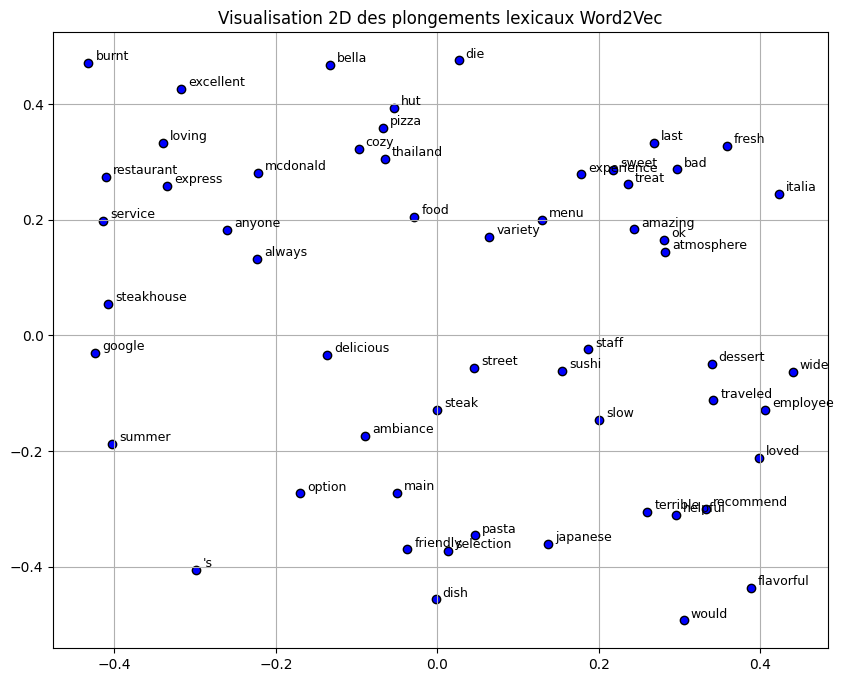

In [13]:
import matplotlib.pyplot as plt

def plot_word_embeddings(model_w2vec):
    words = list(model_w2vec.wv.index_to_key)

    # Récupérer les coordonnées X et Y pour chaque mot
    coords = [model_w2vec.wv[word] for word in words]
    x = [c[0] for c in coords]
    y = [c[1] for c in coords]

    plt.figure(figsize=(10, 8))
    plt.scatter(x, y, color='blue', edgecolors='k')

    # Annoter chaque point avec son mot
    for i, word in enumerate(words):
        plt.annotate(word, xy=(x[i], y[i]), xytext=(5, 2), textcoords='offset points', fontsize=9)

    plt.title("Visualisation 2D des plongements lexicaux Word2Vec")
    plt.grid(True)
    plt.show()

# Appel de la fonction
plot_word_embeddings(model)


### 2.4 Go further
- Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
- Tune Word2Vec hyperparameters and compare the plots.
- Try dimensionality reduction (PCA/t-SNE) for richer visualizations.

In [15]:
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from gensim.models.phrases import Phrases, Phraser

# 1. Tokenisation et nettoyage de base
stop_words = set(stopwords.words('english'))
tokenized_corpus = []

for review in data['Review']:
    tokens = word_tokenize(review.lower())
    cleaned = [tok for tok in tokens if tok not in string.punctuation and tok not in stop_words]
    tokenized_corpus.append(cleaned)

# 2. Détection des Bigrames (ex: "pizza", "hut" -> "pizza_hut")
phrases = Phrases(tokenized_corpus, min_count=1, threshold=2)
bigram_transformer = Phraser(phrases)
corpus_with_bigrams = [bigram_transformer[sent] for sent in tokenized_corpus]

# 3. Application du Stemming vs Lemmatisation
stemmer = PorterStemmer()
corpus_stemmed = [[stemmer.stem(word) for word in sent] for sent in corpus_with_bigrams]

print("Avant (Brut) :", data['Review'][6])
print("Après (Bigrames + Stemming) :", corpus_stemmed[6])

Avant (Brut) : I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
Après (Bigrames + Stemming) : ['terribl', 'experi', 'pizza', 'hut', 'pizza', 'burnt', 'servic', 'slow']


In [16]:
# Entraînement d'un modèle plus robuste (vrai espace sémantique)
model_v2 = Word2Vec(
    sentences=corpus_with_bigrams,
    vector_size=100,  # Dimension augmentée
    window=5,         # Fenêtre contextuelle plus large
    min_count=1,
    workers=2,
    seed=42
)

print(f"Nouvelle taille des vecteurs : {model_v2.wv.vector_size}")

Nouvelle taille des vecteurs : 100


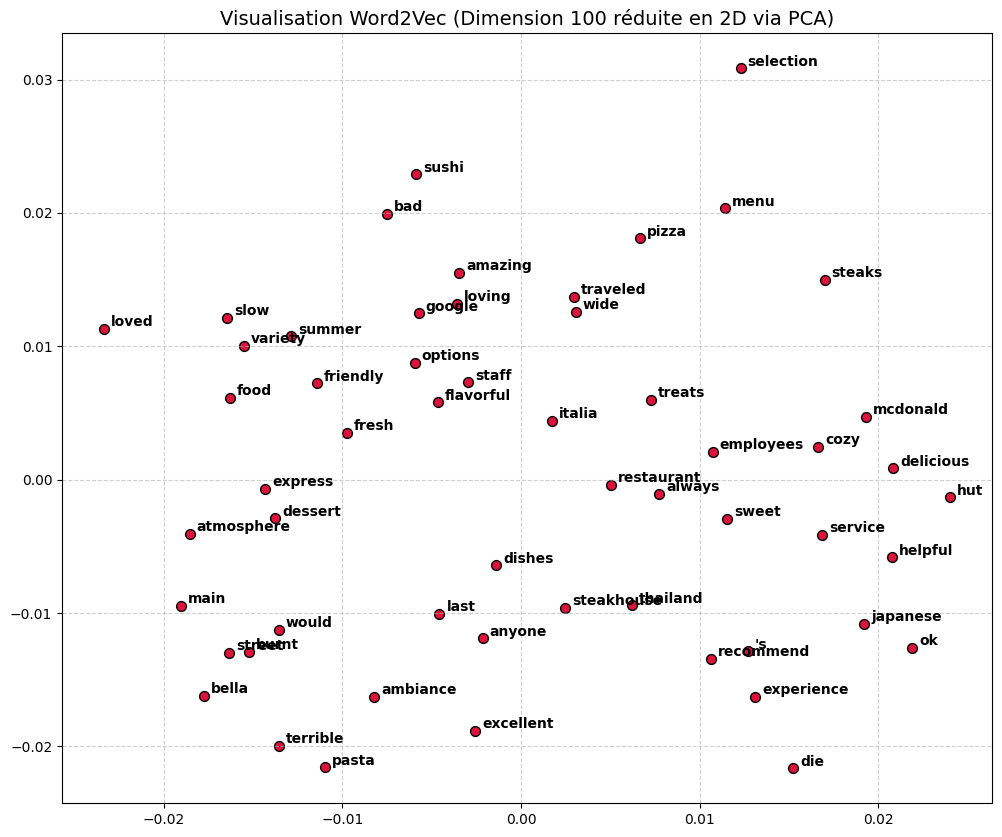

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_advanced_embeddings(model, title):
    words = list(model.wv.index_to_key)

    # Récupérer tous les vecteurs de dimension 100
    vectors = np.array([model.wv[word] for word in words])

    # Réduire de 100 à 2 dimensions avec PCA
    pca = PCA(n_components=2, random_state=42)
    vectors_2d = pca.fit_transform(vectors)

    # Graphique
    plt.figure(figsize=(12, 10))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], color='crimson', edgecolors='k', s=50)

    for i, word in enumerate(words):
        plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), xytext=(5, 2),
                     textcoords='offset points', fontsize=10, weight='bold')

    plt.title(title, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Affichage du nouveau graphique enrichi
plot_advanced_embeddings(model_v2, "Visualisation Word2Vec (Dimension 100 réduite en 2D via PCA)")